In [173]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [174]:
data = [
    # HIGH TORQUE
    ["R1", 50, "steel", "permanent", "air", "high_torque"],
    ["R2", 52, "steel", "permanent", "air", "high_torque"],
    ["R3", 90, "steel", "permanent", "air", "high_torque"],

    # LOW POWER
    ["R4", 30, "aluminum", "none", "passive", "low_power"],
    ["R5", 28, "aluminum", "none", "passive", "low_power"],
    ["R6", 60, "aluminum", "none", "passive", "low_power"],

    # HIGH SPEED
    ["R7", 60, "steel", "induction", "air", "high_speed"],
    ["R8", 62, "steel", "induction", "air", "high_speed"],
    ["R9", 110, "steel", "induction", "air", "high_speed"],

    # MEDIUM
    ["R10", 35, "copper", "permanent", "air", "medium"],
    ["R11", 36, "copper", "permanent", "air", "medium"],
    ["R12", 80, "copper", "permanent", "air", "medium"]
]

df = pd.DataFrame(data, columns=[
    "id", "diameter", "material", "magnet", "cooling", "function"
])

In [175]:
df_encoded = pd.get_dummies(df, columns=[
    "material", "magnet", "cooling", "function"
])

df_encoded.set_index("id", inplace=True)

scaler = StandardScaler()
df_encoded["diameter"] = scaler.fit_transform(df_encoded[["diameter"]])

In [176]:
cos_sim = cosine_similarity(df_encoded)
cos_sim_df = pd.DataFrame(cos_sim, index=df["id"], columns=df["id"])

In [177]:
def semantic_similarity(r1, r2):
    score = 0
    
    if r1["function"] == r2["function"]:
        score += 2
    if r1["material"] == r2["material"]:
        score += 1
    if r1["magnet"] == r2["magnet"]:
        score += 1
        
    return score / 4

In [178]:
semantic_matrix = []

for i in range(len(df)):
    row = []
    for j in range(len(df)):
        row.append(semantic_similarity(df.iloc[i], df.iloc[j]))
    semantic_matrix.append(row)

semantic_df = pd.DataFrame(semantic_matrix, index=df["id"], columns=df["id"])

In [179]:
hybrid_df = semantic_df * (1 + cos_sim_df)

In [180]:
def is_relevant(r1, r2):
    if r1["function"] != r2["function"]:
        return 0
    
    if abs(r1["diameter"] - r2["diameter"]) < 25:
        return 1
    
    return 0

In [181]:
def precision_at_k(sim_matrix, df, rotor_id, k=3):
    top_k = sim_matrix[rotor_id].sort_values(ascending=False).index[1:k+1]
    r1 = df[df["id"] == rotor_id].iloc[0]
    
    correct = 0
    for r in top_k:
        r2 = df[df["id"] == r].iloc[0]
        correct += is_relevant(r1, r2)
        
    return correct / k

In [182]:
cos_scores = [precision_at_k(cos_sim_df, df, r) for r in df["id"]]
sem_scores = [precision_at_k(semantic_df, df, r) for r in df["id"]]
hyb_scores = [precision_at_k(hybrid_df, df, r) for r in df["id"]]

print("FINAL RESULTS:")
print("Cosine:", round(np.mean(cos_scores), 3))
print("Semantic:", round(np.mean(sem_scores), 3))
print("Hybrid:", round(np.mean(hyb_scores), 3))

FINAL RESULTS:
Cosine: 0.222
Semantic: 0.333
Hybrid: 0.222


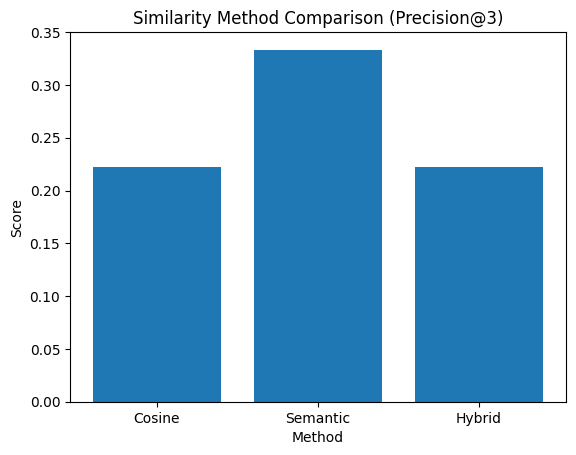

In [183]:
methods = ["Cosine", "Semantic", "Hybrid"]
scores = [np.mean(cos_scores), np.mean(sem_scores), np.mean(hyb_scores)]

plt.figure()
plt.bar(methods, scores)
plt.title("Similarity Method Comparison (Precision@3)")
plt.xlabel("Method")
plt.ylabel("Score")
plt.show()